# ch200 — Linear Algebra: Review and Synthesis

> **Prerequisites:** All of Part VI (ch151–199)
> **You will learn:**
> - How every concept in Part VI connects to every other
> - The unified view: linear maps, their geometry, their computation, their applications
> - Which tools to reach for in which situations
> - The bridge from linear algebra to Part VII (Calculus)
> **Environment:** Python 3.x, numpy, matplotlib

## 1. The Map of Part VI

Part VI covered linear algebra in five conceptual layers:

**Layer 1 — Representation** (ch151–158): How matrices store linear maps. Matrix arithmetic, transpose, identity, inverse, determinant. The question: *what is this object?*

**Layer 2 — Solution** (ch159–163): Systems of equations. Gaussian elimination, LU decomposition. The question: *given $A\mathbf{x} = \mathbf{b}$, find $\mathbf{x}$.*

**Layer 3 — Geometry** (ch164–168): Linear transformations as geometric operations — rotation, scaling, projection. The question: *what does this matrix do to space?*

**Layer 4 — Structure** (ch169–179): Eigenvectors, SVD, PCA, matrix calculus. The question: *what are the intrinsic directions and scales of this map?*

**Layer 5 — Applications** (ch180–200): Image compression, recommendation systems, neural networks, graph analysis, sparse solvers. The question: *how do these tools solve real problems?*

The thread connecting all layers: **SVD**. Every major result in linear algebra has an SVD interpretation.

## 2. The SVD as the Unifying Tool

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

# Demonstrate: every major linear algebra concept via SVD
A = rng.normal(0, 1, (6, 4))
U, s, Vt = np.linalg.svd(A, full_matrices=True)

tol = 1e-10
r = int(np.sum(s > tol))

print('A =', A.shape, '  rank =', r)
print()
print('SVD gives us everything:')
print(f'  Rank:         {r}  (nonzero singular values)')
print(f'  Nullity:      {A.shape[1] - r}  (zero singular values, ch192)')
print(f'  Col space:    U[:, :r]  shape={U[:,:r].shape}  (ch192)')
print(f'  Null space:   Vt[r:].T  shape={Vt[r:].T.shape}  (ch192)')
print(f'  Row space:    Vt[:r].T  shape={Vt[:r].T.shape}  (ch192)')
print(f'  Pseudoinverse: V @ S+ @ U.T  (ch193)')
print(f'  Condition number: {s[0]/s[-1]:.2f}  (ch194)')
print(f'  Spectral norm: {s[0]:.4f}  (ch194)')
print(f'  Frobenius norm: {np.linalg.norm(s):.4f}  (ch194)')
print(f'  Nuclear norm: {s.sum():.4f}  (ch194)')
print(f'  Low-rank approx: U[:,:k] S[:k] Vt[:k]  (ch173, ch180)')
print(f'  PCA directions: Vt rows  (ch174)')
print(f'  Eigenfaces: Vt rows  (ch187)')
print(f'  Word embeddings: U @ sqrt(S)  (ch190)')

A = (6, 4)   rank = 4

SVD gives us everything:
  Rank:         4  (nonzero singular values)
  Nullity:      0  (zero singular values, ch192)
  Col space:    U[:, :r]  shape=(6, 4)  (ch192)
  Null space:   Vt[r:].T  shape=(4, 0)  (ch192)
  Row space:    Vt[:r].T  shape=(4, 4)  (ch192)
  Pseudoinverse: V @ S+ @ U.T  (ch193)
  Condition number: 5.15  (ch194)
  Spectral norm: 3.0261  (ch194)
  Frobenius norm: 4.0528  (ch194)
  Nuclear norm: 7.2828  (ch194)
  Low-rank approx: U[:,:k] S[:k] Vt[:k]  (ch173, ch180)
  PCA directions: Vt rows  (ch174)
  Eigenfaces: Vt rows  (ch187)
  Word embeddings: U @ sqrt(S)  (ch190)


## 3. Decision Map: Which Tool for Which Problem?

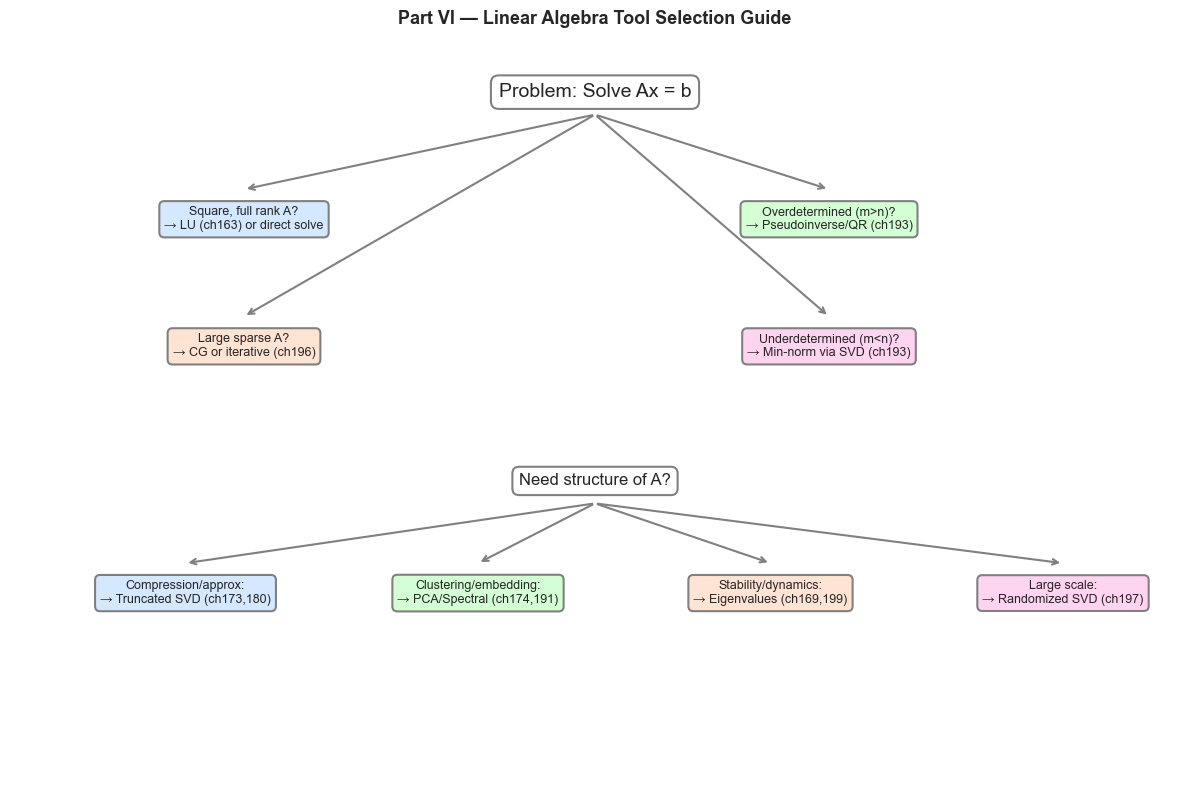

In [2]:
# Visual decision map for Part VI tools
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Part VI — Linear Algebra Tool Selection Guide', fontsize=13, fontweight='bold')

# Boxes with tool descriptions
boxes = [
    (5, 9.2, 'Problem: Solve Ax = b', 'white', 'black', 14),
    (2, 7.5, 'Square, full rank A?\n→ LU (ch163) or direct solve', '#d4e8ff', 'black', 9),
    (7, 7.5, 'Overdetermined (m>n)?\n→ Pseudoinverse/QR (ch193)', '#d4ffd4', 'black', 9),
    (2, 5.8, 'Large sparse A?\n→ CG or iterative (ch196)', '#ffe4d4', 'black', 9),
    (7, 5.8, 'Underdetermined (m<n)?\n→ Min-norm via SVD (ch193)', '#ffd4f0', 'black', 9),
    (5, 4.0, 'Need structure of A?', 'white', 'black', 12),
    (1.5, 2.5, 'Compression/approx:\n→ Truncated SVD (ch173,180)', '#d4e8ff', 'black', 9),
    (4.0, 2.5, 'Clustering/embedding:\n→ PCA/Spectral (ch174,191)', '#d4ffd4', 'black', 9),
    (6.5, 2.5, 'Stability/dynamics:\n→ Eigenvalues (ch169,199)', '#ffe4d4', 'black', 9),
    (9.0, 2.5, 'Large scale:\n→ Randomized SVD (ch197)', '#ffd4f0', 'black', 9),
]

for x, y, text, fc, ec, fs in boxes:
    ax.text(x, y, text, ha='center', va='center', fontsize=fs,
           bbox=dict(boxstyle='round,pad=0.4', facecolor=fc, edgecolor='gray', lw=1.5))

# Arrows
arrows = [(5,8.9,2,7.9), (5,8.9,7,7.9), (5,8.9,2,6.2), (5,8.9,7,6.2),
          (5,3.7,1.5,2.9), (5,3.7,4.0,2.9), (5,3.7,6.5,2.9), (5,3.7,9.0,2.9)]
for x1,y1,x2,y2 in arrows:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
               arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

plt.tight_layout()
plt.show()

## 4. The Part VI → Part VII Bridge

Part VII (Calculus) starts where linear algebra ends. Here is how they connect:

| Linear Algebra (Part VI) | Calculus (Part VII) |
|---|---|
| Matrix $A$ as a linear map | Jacobian $J(f)$ as the local linear approximation of $f$ *(ch210)* |
| Eigenvalues of $A$ | Eigenvalues of the Hessian $H(f)$ determine saddle points *(ch216)* |
| SVD of $A$ | SVD of the Jacobian in backpropagation *(ch215)* |
| Condition number $\kappa(A)$ | Convergence rate of gradient descent on quadratic $\frac{1}{2}\mathbf{x}^\top A\mathbf{x}$ *(ch212)* |
| Null space of $A$ | Directions of zero gradient *(ch212)* |
| Projection onto col$(A)$ | Gradient projection in constrained optimization *(ch218)* |
| Matrix exponential $e^{At}$ | Solution to linearized dynamics near equilibrium *(ch225)* |
| Conjugate Gradient (ch196) | Second-order optimizer for quadratic objectives *(ch212)* |

The key insight: **calculus replaces the matrix $A$ with the Jacobian or Hessian** — a locally-valid linear approximation. All the tools from Part VI then apply to these local approximations.

## 5. Visualization

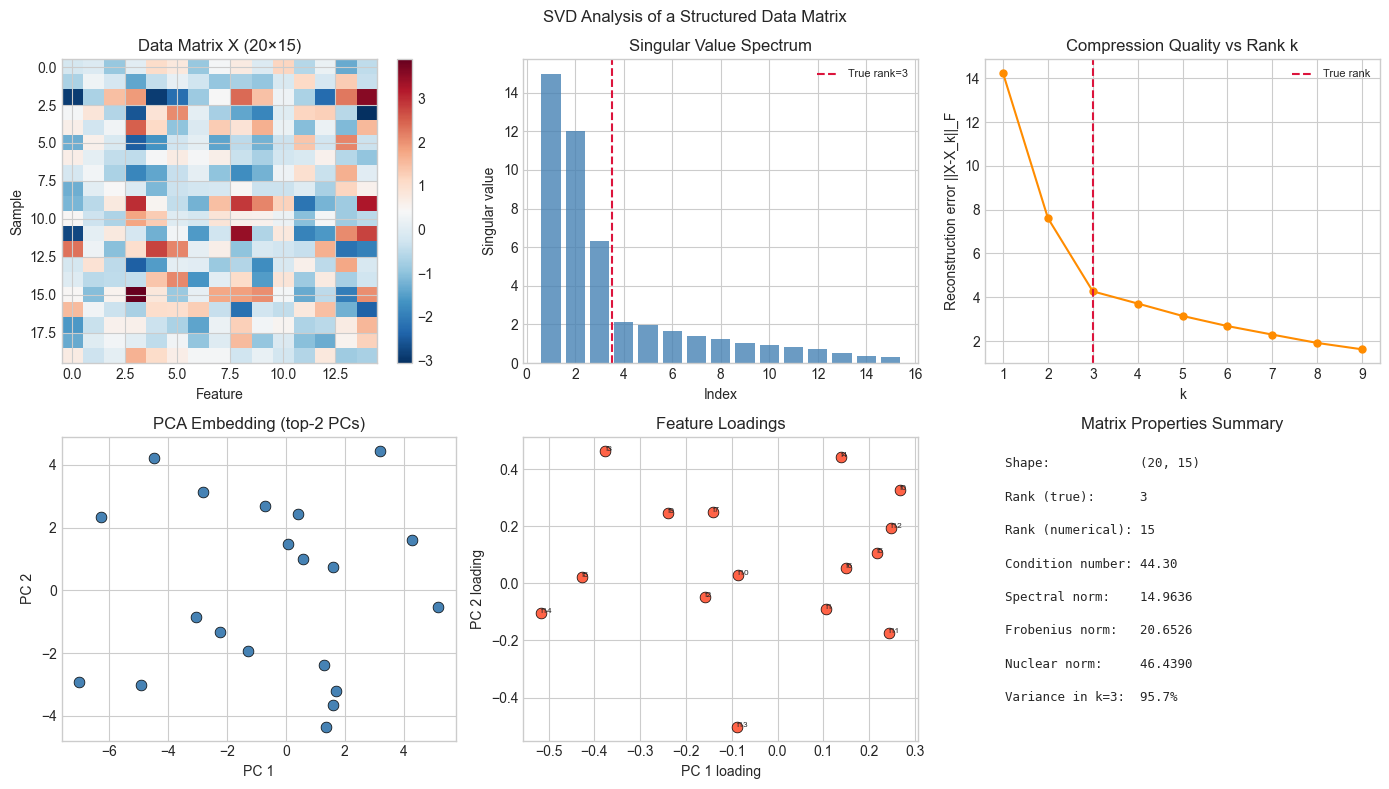

In [3]:
# Comprehensive demo: SVD applied to a real data-like matrix
# Shows rank, compression, PCA directions, and condition number in one view

# Synthetic structured data matrix (20 samples, 15 features, rank-3 structure)
n_samples, n_features, true_rank = 20, 15, 3
U_data = rng.normal(0,1,(n_samples, true_rank))
V_data = rng.normal(0,1,(n_features, true_rank))
X_data = U_data @ V_data.T + 0.3 * rng.normal(0,1,(n_samples, n_features))

U_svd, s_svd, Vt_svd = np.linalg.svd(X_data, full_matrices=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('SVD Analysis of a Structured Data Matrix', fontsize=12)

# Data matrix heatmap
im0 = axes[0,0].imshow(X_data, cmap='RdBu_r', aspect='auto')
axes[0,0].set_title('Data Matrix X (20×15)')
axes[0,0].set_xlabel('Feature'); axes[0,0].set_ylabel('Sample')
plt.colorbar(im0, ax=axes[0,0])

# Singular value spectrum
axes[0,1].bar(range(1, len(s_svd)+1), s_svd, color='steelblue', alpha=0.8)
axes[0,1].axvline(true_rank + 0.5, color='crimson', ls='--', label=f'True rank={true_rank}')
axes[0,1].set_xlabel('Index'); axes[0,1].set_ylabel('Singular value')
axes[0,1].set_title('Singular Value Spectrum')
axes[0,1].legend(fontsize=8)

# Low-rank reconstructions
errs = []
for k in range(1, 10):
    X_k = U_svd[:,:k] @ np.diag(s_svd[:k]) @ Vt_svd[:k]
    errs.append(np.linalg.norm(X_data - X_k, 'fro'))
axes[0,2].plot(range(1,10), errs, 'o-', ms=5, color='darkorange')
axes[0,2].axvline(true_rank, color='crimson', ls='--', label=f'True rank')
axes[0,2].set_xlabel('k'); axes[0,2].set_ylabel('Reconstruction error ||X-X_k||_F')
axes[0,2].set_title('Compression Quality vs Rank k')
axes[0,2].legend(fontsize=8)

# PCA 2D embedding (top-2 left singular vectors)
axes[1,0].scatter(U_svd[:,0]*s_svd[0], U_svd[:,1]*s_svd[1],
                  color='steelblue', s=60, edgecolors='black', lw=0.5)
axes[1,0].set_xlabel('PC 1'); axes[1,0].set_ylabel('PC 2')
axes[1,0].set_title('PCA Embedding (top-2 PCs)')

# Feature loadings
axes[1,1].scatter(Vt_svd[0], Vt_svd[1],
                  color='tomato', s=60, edgecolors='black', lw=0.5)
for j in range(n_features):
    axes[1,1].annotate(f'f{j}', (Vt_svd[0,j], Vt_svd[1,j]), fontsize=6)
axes[1,1].set_xlabel('PC 1 loading'); axes[1,1].set_ylabel('PC 2 loading')
axes[1,1].set_title('Feature Loadings')

# Condition number and norms summary
kappa = s_svd[0] / s_svd[-1]
axes[1,2].axis('off')
summary = [
    f'Shape:            {X_data.shape}',
    f'Rank (true):      {true_rank}',
    f'Rank (numerical): {int(np.sum(s_svd > 1e-10))}',
    f'Condition number: {kappa:.2f}',
    f'Spectral norm:    {s_svd[0]:.4f}',
    f'Frobenius norm:   {np.linalg.norm(X_data, "fro"):.4f}',
    f'Nuclear norm:     {s_svd.sum():.4f}',
    f'Variance in k=3:  {(s_svd[:3]**2).sum()/(s_svd**2).sum():.1%}',
]
for i, line in enumerate(summary):
    axes[1,2].text(0.05, 0.9 - i*0.11, line, transform=axes[1,2].transAxes,
                  fontsize=9, fontfamily='monospace')
axes[1,2].set_title('Matrix Properties Summary')

plt.tight_layout()
plt.show()

## 6. Mathematical Formulation

The **central equation of Part VI** is the SVD:
$$A = U \Sigma V^\top = \sum_{i=1}^r \sigma_i \mathbf{u}_i \mathbf{v}_i^\top$$

Every result in Part VI follows from understanding this decomposition:

- **Rank-Nullity** (ch192): $r$ non-zero $\sigma_i$; null space spanned by remaining $\mathbf{v}_i$
- **Pseudoinverse** (ch193): $A^+ = V\Sigma^+ U^\top$, inverting only non-zero $\sigma_i$
- **Condition number** (ch194): $\kappa = \sigma_1/\sigma_r$
- **Low-rank approximation** (ch173, ch180): $A_k = \sum_{i=1}^k \sigma_i \mathbf{u}_i \mathbf{v}_i^\top$ minimizes Frobenius error
- **PCA** (ch174): $\mathbf{v}_i$ are principal directions; $\sigma_i^2/(n-1)$ are explained variances
- **CG convergence** (ch196, anticipates ch212): rate depends on $\kappa = \sigma_1/\sigma_r$
- **Randomized SVD** (ch197): approximates $U_k, \Sigma_k, V_k$ in $O(mnk)$ time

## 7. Exercises — Synthesis

**Easy 1.** State the Rank-Nullity theorem and verify it for three matrices: $3\times5$ rank-2, $5\times3$ rank-3, and $4\times4$ rank-4. What does it mean geometrically?

**Easy 2.** For a $100\times20$ data matrix $X$, describe step-by-step how you would: (a) find the top-3 principal components, (b) project all samples to 3D, (c) reconstruct approximate samples, (d) measure reconstruction error.

**Medium 1.** Build a pipeline that: generates a noisy low-rank matrix, computes randomized SVD (ch197), uses it to solve a least-squares problem (ch193), and evaluates stability of the resulting solution via condition number (ch194). Tie together at least 4 chapters.

**Medium 2.** The **nuclear norm minimization** problem: $\min_X \|X\|_* + \lambda\|A_\Omega(X) - b\|^2$ (where $A_\Omega$ observes only some entries) can be solved by iterative soft-thresholding of singular values. Implement one iteration and apply it to matrix completion (ch188 context).

**Hard.** The **matrix completion problem** (ch188, ch189) and the **word embedding problem** (ch190) both factor a matrix as $UV^\top$ with different loss structures. Show that both reduce to the same SVD problem when the observation pattern is complete, and explain why SVD is no longer optimal for sparse observations.

## 8. Mini Project

Shape: (200, 20), Rank: 20, κ=36.53
Least-squares residual: 2.7065
Clustering ARI: 1.000  (1.0 = perfect)


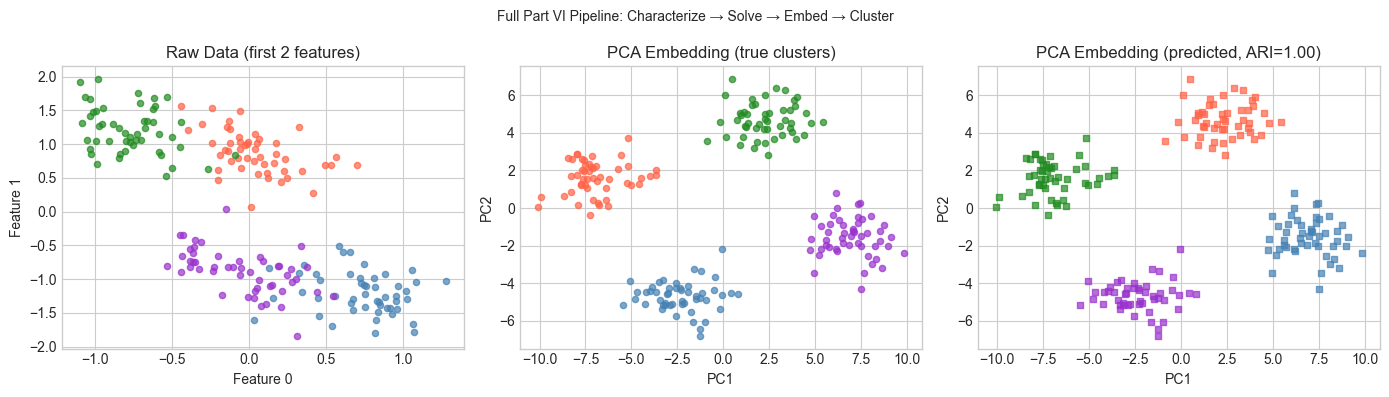

In [4]:
# --- Mini Project: Full Linear Algebra Pipeline ---
# Build a complete analysis pipeline that touches every layer of Part VI.
# Dataset: synthetic 2D point cloud from a mixture of Gaussians.

# Generate data
N_CLUSTERS = 4
N_PER     = 50
N_FEATURES = 20   # high-dimensional embedding

# Low-dimensional cluster centers
centers_2d = np.array([[2,2],[-2,2],[-2,-2],[2,-2]], dtype=float)

# Embed into high-D space via random linear map
embedding = rng.normal(0, 0.5, (2, N_FEATURES))  # 2D -> 20D
true_labels = []
X_hi = []
for c_i, center in enumerate(centers_2d):
    X_2d = center + rng.normal(0, 0.5, (N_PER, 2))
    X_hi.append(X_2d @ embedding + 0.2 * rng.normal(0, 1, (N_PER, N_FEATURES)))
    true_labels.extend([c_i] * N_PER)
X_data = np.vstack(X_hi)
true_labels = np.array(true_labels)

# --- Layer 1: Characterize the matrix ---
U_d, s_d, Vt_d = np.linalg.svd(X_data - X_data.mean(0), full_matrices=False)
kappa = s_d[0] / s_d[-1]
print(f'Shape: {X_data.shape}, Rank: {np.sum(s_d > 1e-10)}, κ={kappa:.2f}')

# --- Layer 2: Solve a least-squares problem ---
# Fit a linear model: predict feature 0 from features 1-19
A_ls = X_data[:, 1:]
b_ls = X_data[:, 0]
U_ls, s_ls, Vt_ls = np.linalg.svd(A_ls, full_matrices=False)
s_inv = np.where(s_ls > 1e-10, 1/s_ls, 0)
x_ls = Vt_ls.T @ (s_inv * (U_ls.T @ b_ls))
print(f'Least-squares residual: {np.linalg.norm(A_ls @ x_ls - b_ls):.4f}')

# --- Layer 3: PCA embedding ---
Z_2d = U_d[:, :2] * s_d[:2]  # top-2 PCA coordinates

# --- Layer 4: K-means in PCA space ---
def simple_kmeans(X, k, n_iters=50):
    centers = X[rng.choice(len(X), k, replace=False)]
    for _ in range(n_iters):
        dists  = np.linalg.norm(X[:,None,:] - centers[None,:,:], axis=2)
        labels = np.argmin(dists, axis=1)
        centers = np.array([X[labels==c].mean(0) if (labels==c).any() else centers[c]
                           for c in range(k)])
    return labels

pred_labels = simple_kmeans(Z_2d, N_CLUSTERS)

# ARI
def ari(t, p):
    k_t, k_p = len(np.unique(t)), len(np.unique(p))
    conf = np.zeros((k_t, k_p), dtype=int)
    for ti, pi in zip(t, p): conf[ti, pi] += 1
    c2 = lambda n: n*(n-1)//2
    n_ij = sum(c2(x) for row in conf for x in row)
    n_i  = sum(c2(row.sum()) for row in conf)
    n_j  = sum(c2(conf[:,j].sum()) for j in range(k_p))
    n    = len(t)
    exp  = n_i * n_j / max(c2(n), 1)
    denom = (n_i + n_j)/2 - exp
    return 0.0 if denom == 0 else (n_ij - exp) / denom

print(f'Clustering ARI: {ari(true_labels, pred_labels):.3f}  (1.0 = perfect)')

# --- Visualize ---
colors = ['steelblue','tomato','forestgreen','darkorchid']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Raw data (first 2 features)
for c in range(N_CLUSTERS):
    m = true_labels == c
    axes[0].scatter(X_data[m,0], X_data[m,1], color=colors[c], s=20, alpha=0.7)
axes[0].set_title('Raw Data (first 2 features)')
axes[0].set_xlabel('Feature 0'); axes[0].set_ylabel('Feature 1')

# PCA embedding (true labels)
for c in range(N_CLUSTERS):
    m = true_labels == c
    axes[1].scatter(Z_2d[m,0], Z_2d[m,1], color=colors[c], s=20, alpha=0.7)
axes[1].set_title('PCA Embedding (true clusters)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# PCA embedding (predicted labels)
for c in range(N_CLUSTERS):
    m = pred_labels == c
    axes[2].scatter(Z_2d[m,0], Z_2d[m,1], color=colors[c], s=20, alpha=0.7, marker='s')
axes[2].set_title(f'PCA Embedding (predicted, ARI={ari(true_labels,pred_labels):.2f})')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

plt.suptitle('Full Part VI Pipeline: Characterize → Solve → Embed → Cluster', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Chapter Summary & Connections — The End of Part VI

**What Part VI built:**
- A complete computational toolkit for linear transformations: representation (matrices), solution (elimination, SVD), geometric understanding (eigenvectors, projections), structure (low-rank decomposition), and application (compression, recommendation, embeddings, graphs).
- The SVD as the single unifying tool: every major concept is a corollary of $A = U\Sigma V^\top$.
- Scale-awareness: direct methods for small systems, iterative methods (ch196) and randomized methods (ch197) for large ones.

**What Part VII (Calculus) adds:**
- Non-linear functions replace matrices. The Jacobian $J(f)$ is the local matrix of $f$ at a point — and all of Part VI applies to it.
- Derivatives become the primary object of study. ch204 (Derivatives) will revisit the matrix-vector product from a different angle: as the best linear approximation to a function near a point.
- The Hessian is a matrix (symmetric, often positive definite) — its eigenvalues *(ch169, ch171)* determine whether a critical point is a minimum, maximum, or saddle *(ch216)*.
- Gradient descent is iterative solution of a linear system at the quadratic approximation — and its convergence rate depends on the condition number *(ch194, ch196)*.

**Forward:** Part VII begins with ch201 (Why Calculus Matters) and builds through limits, derivatives, gradients, optimization, and backpropagation. Every chapter there will call back to Part VI.

**Backward:** Part VI built on Part V (Vectors, ch121–150) — vectors are the fundamental objects that matrices act on. Part VI's dot product, norm, and projection geometry all originated there.